## <span style="color:blue"> Lezione 1 </span>



In [9]:

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### Teorema del limite centrale

Siano date $N$  variabili casuali indipendenti $x_i$, estratte da una distribuzione $p(x)$, di modo che $p_N(x_1,...,x_N)=p(x_1)...p(x_N)$.
Sia $\langle x_i \rangle =\mu$ il valore medio, e sia $\langle x_i^2\rangle -\langle x_i \rangle^2 =\sigma^2 $ la varianza. Se  $\sigma$ è finita, vale il 
teorema del limite centrale: data $$A_N=\frac{1}{N}\sum_{i=1}^N x_i,$$ allora: 
1. $ \langle A_N \rangle=\mu $
2. $\sigma_A^2=\langle A_N^2 \rangle -\langle A_N \rangle^2= \frac{\sigma^2}{N}$
3. Per $N\gg 1$ $A_N$ segue una distribuzione di probabilità gaussiana: $P(A_N)\ \substack{\longrightarrow \\ N\to + \infty} \ \mathcal{N}(\mu,\frac{\sigma^2}{N} )$. 


con $$ \mathcal{N}(\mu', \sigma'^2) = \frac{1}{ \sqrt{2\pi\sigma'^2}} e^{-\frac{\left(x - \mu'\right)^2}{2\sigma'^2}} $$
 


### <span style="color:DodgerBlue"> Esercizi 1.1.1 e 1.1.2 </span>



Il generatore random fornito ha come funzione base `Rannyu()`, che genera un numero pseudocasuale distribuito uniformemente nell'intervallo $[0,1]$. 
Si vuole stimare il valore medio $\langle r \rangle $  (es 1.1.1) e la varianza $\sigma^2$  (es 1.1.2) dei numeri prodotti dal generatore. 

I risultati attesi sono: 

- $\langle r \rangle =\int_0^1 r \mathrm{d}r =1/2 \ $ per il valore medio

- $\sigma^2=\int_0^1 (r-1/2)^2\mathrm{d}r =1/12 \ $ per la varianza 



A tale scopo si effettuano $M$ estrazioni di un numero casuale $r$ tramite `Rannyu()`. Le quantità cercate verranno calcolate per ciascun $r$ estratto e poi mediate. 
Per il calcolo delle incertezze, si fa ricorso al metodo del _data blocking_, che permette di garantire l'indipendenza delle variabili, necessaria per applicare il teorema del limite centrale. 

### Data blocking 

Siano date $M$ variabili casuali $x_k$, con valore medio $\langle x \rangle $. Esse vengono suddivise in $N$ blocchi di lunghezza $L=M/N$. Si indicherà con $x_{ij} $ la j-esima variabile appartenente all'i-esimo blocco. Per ciascun blocco $i$ si calcola la media $X_i =  \frac{1}{L} \sum_{j=1}^L x_{ij}$.

Le $N$ medie $X_i$ si possono considerare indipendenti, a patto di scegliere $L$ sufficientemente grande. Ad esse, quindi, è possibile applicare il teorema del limite centrale: la "media delle medie" $ S= \frac{1}{N} \sum_{i=1}^N X_i $, per $N \gg 1$  è distribuita lungo una gaussiana centrata in $\langle X_i \rangle=  \langle x \rangle $, e con varianza $ \langle \left( X_i - \langle X_i \rangle \right) ^2 \rangle / N$. 




Si utilizzeranno $M=100000$ estrazioni  e $N=100$ blocchi.
Data la simmetria dei due esercizi, sono stati eseguiti insieme in un unico main. Nella cella sottostante, vengono caricati i risultati delle simulazioni. 


In [10]:

M=100000 #steps
N=100 #numero blocchi
L=M/N #grandezza blocco 



mean,mean_err,var,var_err=np.loadtxt("l_01_es_1_1-2/results.csv", delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(1,N+1)
n*=int(L)

Per l'esercizio 1.1.1, si ottiene il seguente grafico dello scostamento del valor medio rispetto al valore atteso (1/2): 

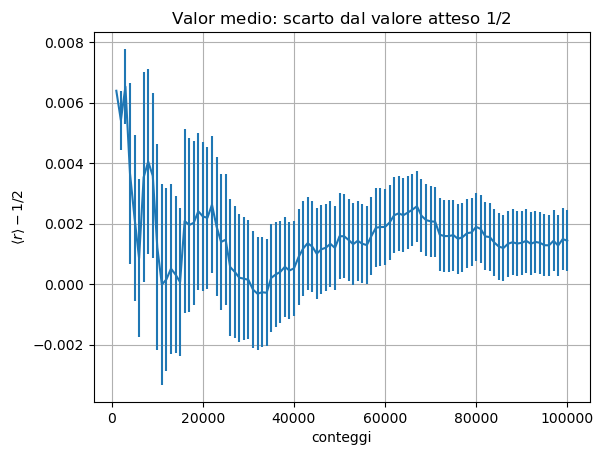

In [11]:
plt.errorbar(n,mean-1/2,mean_err) #plot delle oscillazioni della media (col loro errore) attorno al valore atteso (1/2)

plt.title(r"Valor medio: scarto dal valore atteso $1/2$")
plt.grid(True)
plt.xlabel("conteggi")
plt.ylabel(r"$ \langle r \rangle - 1/2$")
plt.show()

Per l'esercizio 1.1.2, si ottiene il seguente grafico dello scostamento della varianza rispetto al valore atteso (1/12): 

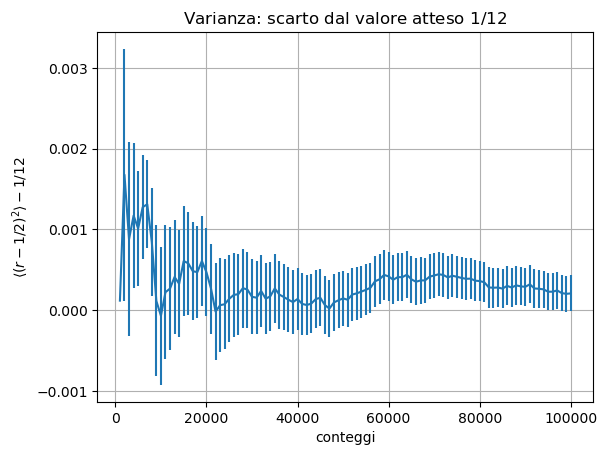

In [12]:


plt.errorbar(n,var-1/12,var_err)#plot delle oscillazioni della varianza (col loro errore) attorno al valore atteso (1/12)

plt.title(r"Varianza: scarto dal valore atteso $1/12$")
plt.grid(True)
plt.xlabel("conteggi")
plt.ylabel(r"$ \langle (r-1/2)^2 \rangle -1/12$")
plt.show()

### <span style="color:DodgerBlue"> Esercizio 1.1.3 </span>

Per verificare se i numeri prodotti dal generatore pseudorandom sono effettivamente distribuiti secondo una distribuzione uniforme, si può effettuare un test del $\chi^2$.

Esso fornisce una misura di quanto il numero di eventi di un certo tipo $i$ osservati $O_i$ si discosti dal valore atteso $E_i$: 

$$\chi^2 = \sum_{i} \frac{\left( O_i - E_i \right)^2}{E_i}.$$


L'$E_i$ al denominatore è una stima della varianza. Infatti, la probabilità di ottenere esattamente $k$ realizzazioni su $n$ tentativi di un certo evento che ha probabilità $p$ di accadere è descritta da una distribuzione binomiale. Essa ha valor medio $\mu=np$ e varianza $\sigma^2=np(1-p)$. Se $p \ll 1$, $\sigma^2 \simeq np=\mu$. 


Nel caso specifico, si suddivide l'intervallo $[0,1]$ in $M=100$ sottointervalli. La probabilità di cadere in ciascun sottointervallo sarà $1/M \ll 1$.

Per $n=10000$ volte viene estratto un numero casuale e, per ogni sottointervallo, si calcola $n_i$ il numero di numeri estratti caduti al suo interno. Si calcola quindi il chi quadro: $$\chi^2=\sum_{i=1}^M \frac{(n_i-n/M)^2}{n/M}. $$ Ripetendo questa operazione per $R$ volte, si costruisce un istogramma dei valori di chi quadro calcolati. Nella cella sottostante, è riportato l'istogramma per $R=100$. 

Il valore medio di X^2 calcolato è:  99.146796


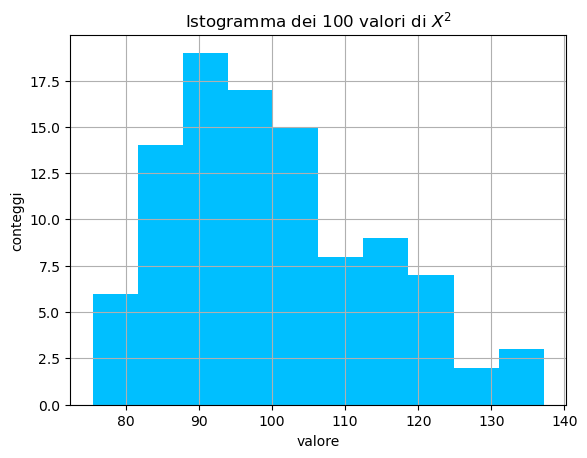

In [13]:


M=100 #numero sottointervalli


chi_square=np.loadtxt("l_01_es_1_3/results.csv",delimiter=",",unpack=True,skiprows=1)



#Mostra l'istogramma dei primi 100 valori di chi_quadro calcolati
plt.hist(chi_square[:100],density=False,color="deepskyblue")
plt.title(rf"Istogramma dei 100 valori di $X^2$")
plt.xlabel("valore")
plt.ylabel("conteggi")
plt.grid(True)

print("Il valore medio di X^2 calcolato è: ", chi_square.mean())


Il valore medio di $X^2$ calcolato è circa pari al numero di gradi di libertà $\nu =99 $ (100 sottointervalli -> 100 $n_i$ , col vincolo $n=\sum_i n_i$ ). Ciò indica un buon accordo con la previsione teorica (distribuzione uniforme dei numeri generati). Per meglio verificare ciò, nella cella sottostante si mette a confronto l'istogramma di R=10000 valori di $X^2$ calcolati con la distribuzione teorica di $X^2$.

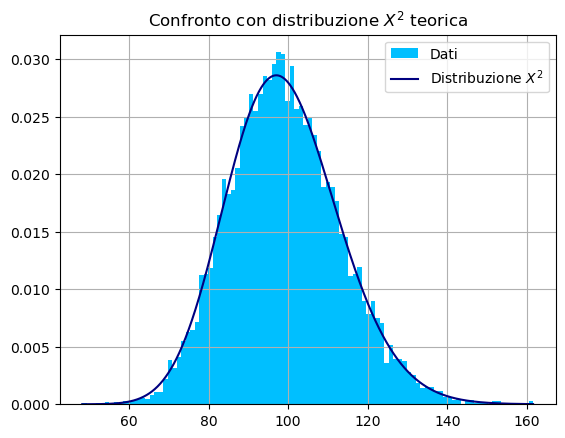

In [14]:


#mostra l'istogramma (con area normalizzata ad 1 ) di 10000 valori di chi_quadro per confronto con distribuzione teorica
min=chi_square.min()
max=chi_square.max()
x=np.linspace(min,max,1000)
plt.hist(chi_square,bins=100,density=True,label="Dati",color="deepskyblue",) 
plt.plot(x,stats.chi2.pdf(x,M-1),label=r"Distribuzione $X^2$",color="navy") #distribuzione teorica (df=M-1)
plt.title(rf"Confronto con distribuzione $X^2$ teorica")
plt.legend()
plt.grid(True)

plt.show()

### <span style="color:DodgerBlue"> Esercizio 1.2 </span>



Lo scopo dell'esercizio è controllare la validità del teorema del limite centrale per le tre distribuzioni:
1.  uniforme su [0,1],
2. esponenziale ( $\lambda=1$) $$p(x) = 
\begin{cases} 
\lambda e^{-\lambda x} & x \ge 0, \\
0 & x < 0.
\end{cases}$$
3. lorentziana ($\Gamma=1, \mu=0$)$$ p(x) = \frac{\Gamma}{\pi  \left[1 + \left(\frac{x - \mu}{\Gamma}\right)^2\right]}$$



per n=10000 volte si calcola la media di N valori estratti, con N=1,2,10,100. 


In [15]:

N={0:1,1:2,2:10,3:100}#numero di valori che concorrono alla media

### Distribuzione uniforme

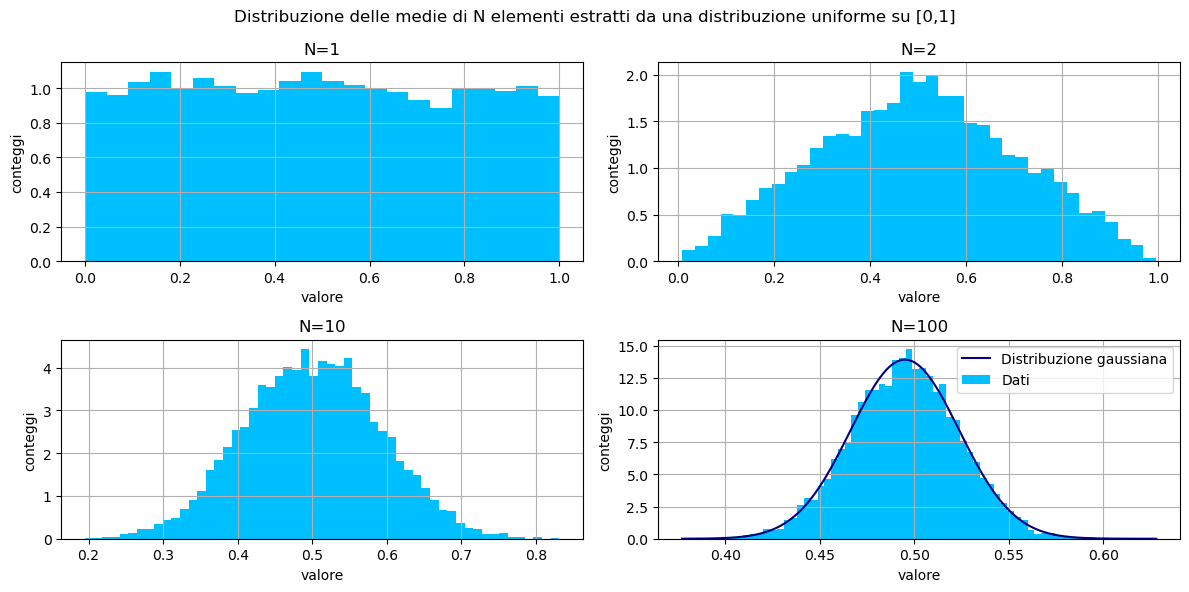

In [16]:
#Distribuzione uniforme

data=np.loadtxt("l_01_es_2/res_uni_dist.csv",delimiter=",",unpack=False, skiprows=1)

fig,axs=plt.subplots(2,2,figsize=[12,6]) 

for i,ax in enumerate(axs.flat):
    ax.hist(data[:,i],density=True,color="deepskyblue",bins="auto") #plot della distribuzione, con area normalizzata a 1 
    ax.set_title(f"N={N[i]}")
    ax.set_xlabel("valore")
    ax.set_ylabel("conteggi")
    ax.grid()

#per N=100, confronto con distribuzione gaussiana
mean=data[:,3].mean()
stdv=data[:,3].std()
max=data[:,3].max()
min=data[:,3].min()
x=np.linspace(min,max,1000) 
gauss=stats.norm.pdf(x,loc=mean,scale=stdv) #distribuzione gaussiana
axs[1,1].plot(x,gauss,color="navy")
axs[1,1].legend(["Distribuzione gaussiana","Dati"])


fig.suptitle("Distribuzione delle medie di N elementi estratti da una distribuzione uniforme su [0,1]")
plt.tight_layout()
plt.show()



La distribuzione uniforme ha varianza finita. Per N variabili indipendenti tratte da essa vale quindi il teorema del limite centrale e la distribuzione delle medie tende, per $N\to +\infty$ , a una gaussiana con valore medio pari alla media dei dati (1/2) e varianza pari alla varianza dei dati ($1/12$) diviso N. 

Nel IV quadrante della figura sopra si può vedere il confronto tra l'istogramma delle medie di 100 valori e la distribuzione gaussiana (con valore medio e varianza ricavati dai dati).

### Distribuzione esponenziale

La distribuzione cumulativa per una variabile esponenziale è la seguente:$$
F(x)= \int_{0}^{x} \mathrm{d}x' \lambda \exp(-\lambda x') = 1- \exp(-\lambda x).$$

Come ogni distribuzione cumulativa, $u=F(x)$ è distribuita uniformemente nell'intervallo $[0,1]$. Nel caso particolare $F(x)$ è inoltre invertibile. Ciò permette di estrarre variabili stocastiche $x$ che seguono una distribuzione esponenziale secondo: $$ x= - \frac{1}{\lambda} \log(1-u),$$
dove $u$ è un numero pseudocasuale distribuito uniformemente nell'intervallo $[0,1)$. 

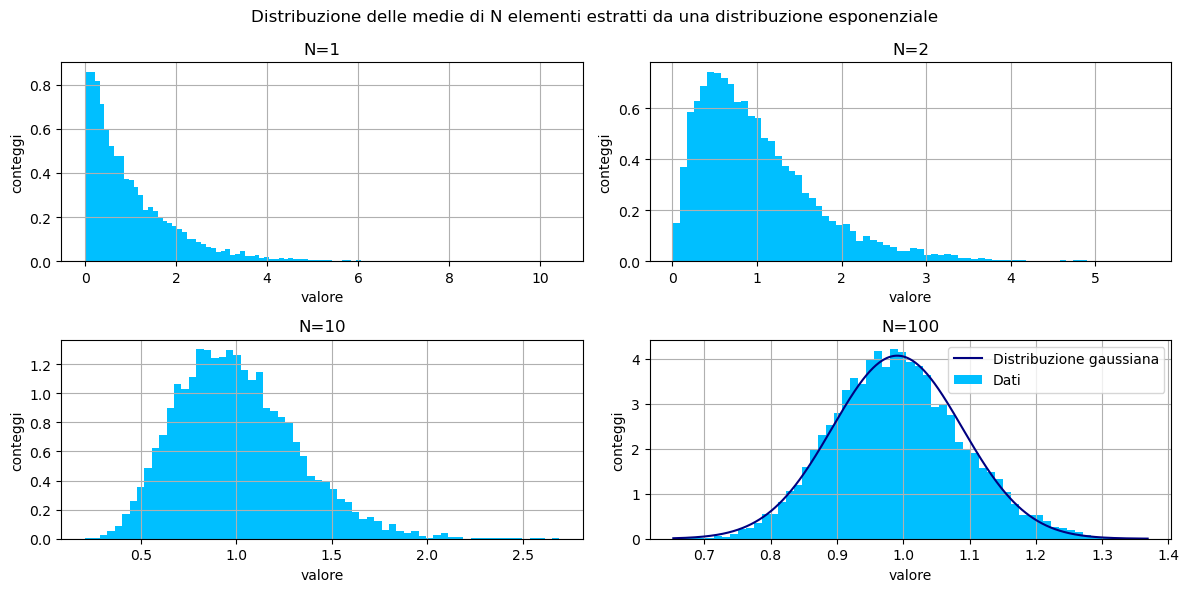

In [17]:

#Distribuzione esponenziale

data=np.loadtxt("l_01_es_2/res_exp_dist.csv",delimiter=",",unpack=False, skiprows=1)


fig,axs=plt.subplots(2,2,figsize=[12,6]) 

for i,ax in enumerate(axs.flat):
    ax.hist(data[:,i],density=True,color="deepskyblue",bins="auto") #plot della distribuzione, con area normalizzata a 1 
    ax.set_title(f"N={N[i]}")
    ax.set_xlabel("valore")
    ax.set_ylabel("conteggi")
    ax.grid()

#per N=100, confronto con distribuzione gaussiana
mean=data[:,3].mean()
stdv=data[:,3].std()
max=data[:,3].max()
min=data[:,3].min()
x=np.linspace(min,max,1000) 
gauss=stats.norm.pdf(x,loc=mean,scale=stdv) #distribuzione gaussiana
axs[1,1].plot(x,gauss,color="navy")
axs[1,1].legend(["Distribuzione gaussiana","Dati"])

fig.suptitle("Distribuzione delle medie di N elementi estratti da una distribuzione esponenziale")
plt.tight_layout()
plt.show()


Anche la distribuzione esponenziale ha varianza finita e  vale il teorema del limite centrale.

Nel IV quadrante della figura sopra si può vedere il confronto tra l'istogramma delle medie di 100 valori e la distribuzione gaussiana (con valore medio e varianza ricavati dai dati).

### Distribuzione lorentziana

Anche la distribuzione cumulativa di una densità di probabilità lorentziana è invertibile. Analogamente al caso precedente, si troverà: $$
x=\Gamma \tan  \left(\pi\left(u-\frac{1}{2}\right)\right) + \mu,$$

dove $u$ è un numero pseudocasuale distribuito uniformemente nell'intervallo $[0,1)$. 

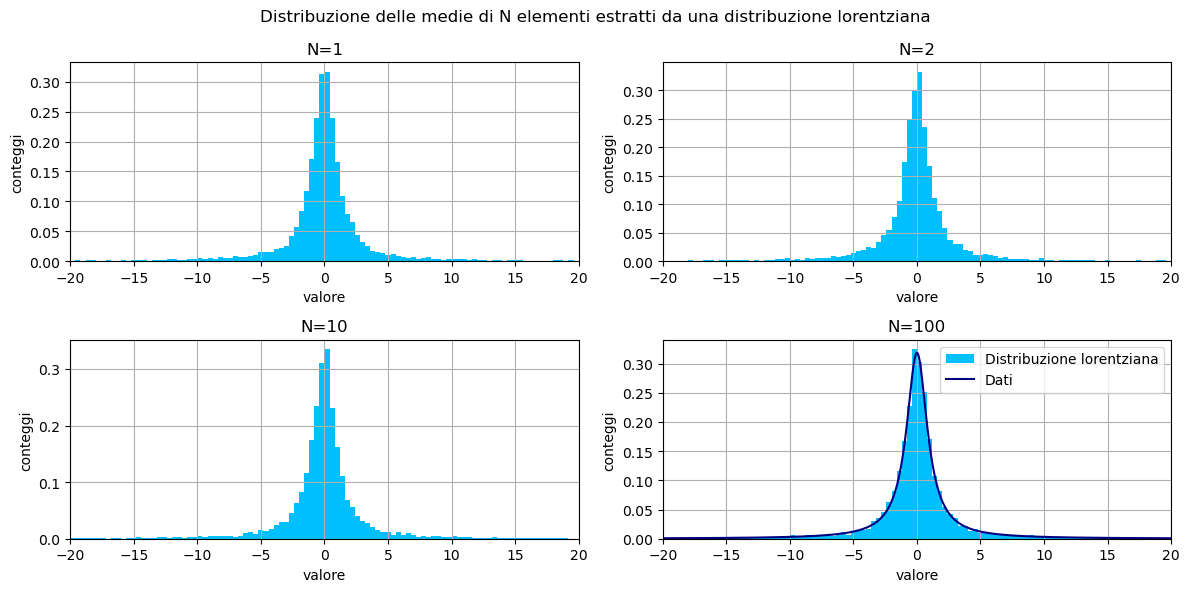

In [ ]:

#Distribuzione lorentziana 

data=np.loadtxt("l_01_es_2/res_lor_dist.csv",delimiter=",",unpack=False, skiprows=1)


fig,axs=plt.subplots(2,2,figsize=[12,6]) 

#limiti per tagliare le code
min=-20
max=20


for i,ax in enumerate(axs.flat):
    conteggi, bins = np.histogram(data[:,i],bins=100,range=(min,max),density=True) #crea un istogramma dei dati, tagliando le code
    ax.stairs(conteggi, bins,fill=True, color="deepskyblue") #plot dell'istogramma creato
    ax.set_title(f"N={N[i]}")
    ax.set_xlabel("valore")
    ax.set_ylabel("conteggi")
    ax.set_xlim([min,max])
    ax.grid()
  

#per N=100, confronto con distribuzione lorentziana
x=np.linspace(min,max,(max-min)*100) 
lor=stats.cauchy.pdf(x,loc=0,scale=1)#distribuzione lorentziana
axs[1,1].plot(x,lor,color="navy")
axs[1,1].legend(["Distribuzione lorentziana","Dati"])

fig.suptitle("Distribuzione delle medie di N elementi estratti da una distribuzione lorentziana")
plt.tight_layout()
plt.show()






La distribuzione lorentziana non ha varianza finita, e quindi non è possibile utilizzare il teorema del limite centrale. Però è stabile (ossia invariante per convoluzione): difatti la distribuzione della media di N variabili indipendenti estratte da una distribuzione lorentziana con parametri $\Gamma, \mu$  è ancora una lorentziana con gli stessi $\Gamma, \mu$ .

Date le code molto lunghe della distribuzione lorentziana, per osservare questo fenomeno si è reso necessario limitare il range dei dati considerati.

### <span style="color:DodgerBlue"> Esercizio 1.3 </span>


Si vuole simulare l'esperimento di Buffon, che consente di stimare il valore di $\pi$. 

Esso utilizza un ago di lunghezza $l$, e un piano con righe verticali separate da una lunghezza $d$. Dev'essere $l<d$, ma non $l << d$. 

Lanciando $N_{\mathrm{thr}}$ volte l'ago, si conta quante volte esso interseca una linea ($N_{\mathrm{hit}}$). Vale: 
$$\lim_{N_{\mathrm{thr}} \to +\infty} \frac {2lN_{\mathrm{thr}}}{N_{\mathrm{hit}} d} =\pi$$


Nello scrivere il codice si è tenuto conto sia dell'invarianza per traslazioni verticali continue (per cui non è necessario estrarre l'ordinata degli estremi dell'ago), sia per traslazioni orizzontali discrete di passo $d$ (per cui l'ascissa del primo estremo dell'ago, $x_1$,  può essere estratta in un intervallo limitato a $[0,d]$). Per controllare se l'ago ha intersecato o meno una linea, è sufficiente controllare se l'ascissa del secondo estremo $x_2$ è tale che $x_2 < 0 $ o $x_2 >d $. 

L'ascissa del secondo estremo è $x_2=x_1 + l \cos \theta$, con $\theta$ estratto uniformemente dall'intervallo $[0,2\pi)$. Si può evitare di usare $\pi$ calcolando direttamente $\cos \theta$: 

1. Si estrae un punto in un quadrato: $p=(x,y)$ con $x,y \in [-1,1]$ estratti uniformemente.
2. Se $p$ non appartiene al cerchio unitario viene scartato.
3. Se $p$ appartiene al cerchio unitario, si calcola il coseno dell'angolo che forma con l'asse delle ascisse: $\cos \theta = x / \sqrt{x^2+y^2}$ e lo si restituisce. 

L'esperimento è stato simulato con i seguenti valori: $l=2.9$,$d=3$, $N=100$ blocchi e $M=10000$ lanci per blocco.

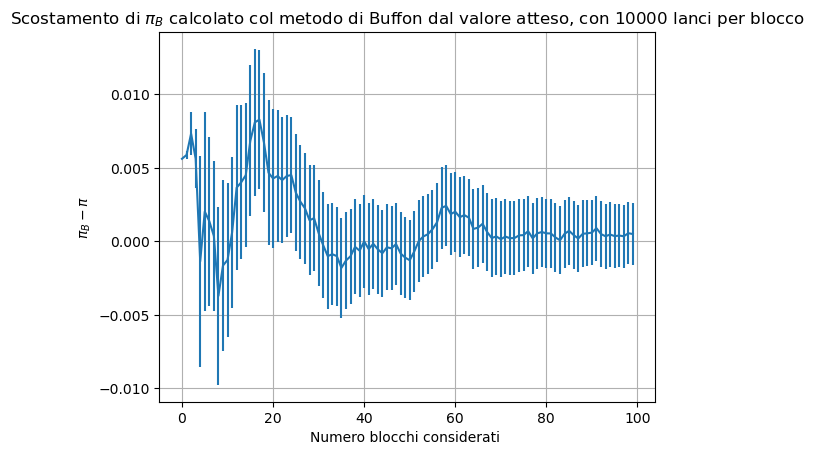

In [19]:
M=10000 #numero lanci per blocco
N=100 #numero blocchi

mean,error=np.loadtxt("l_01_es_3/results.csv", usecols=(0,1), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(N) #progressivo dei blocchi
plt.errorbar(n,mean-np.pi,error) 

plt.title(fr"Scostamento di $\pi_B$ calcolato col metodo di Buffon dal valore atteso, con {M} lanci per blocco")
plt.xlabel("Numero blocchi considerati ")
plt.ylabel(rf"$\pi_B - \pi$")
plt.grid(True)
plt.show()

Dopo $100$ blocchi, lo scostamento del valore calcolato da quello atteso si trova ben entro una $\sigma$ da $0$. 